In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from elasticsearch import Elasticsearch

es = Elasticsearch("http://localhost:9200")
print(es.info()['version']['number'])

8.13.0


In [2]:
def extract_metricbeat(days=30, batch_size=10000):
    """
    Pulls Metricbeat documents from Elasticsearch using the scroll API,
    which is designed for retrieving large result sets efficiently.
    """
    query = {
        "query": {
            "range": {"@timestamp": {"gte": f"now-{days}d"}}
        },
        "_source": [
            "@timestamp", "host.name", "agent.hostname",
            "system.cpu.total.pct",
            "system.load.1", "system.load.5", "system.load.15",
            "system.memory.actual.used.pct",
            "system.memory.actual.used.bytes",
            "system.network.name", "system.network.in.bytes",
            "system.network.out.bytes", "system.network.in.packets",
            "system.network.out.packets"
        ],
        "sort": [{"@timestamp": {"order": "asc"}}]
    }
    
    records = []
    response = es.search(index="metricbeat-*", body=query, size=batch_size, scroll="2m")
    scroll_id = response['_scroll_id']
    
    while True:
        hits = response['hits']['hits']
        if not hits:
            break
        for hit in hits:
            records.append(hit['_source'])
        response = es.scroll(scroll_id=scroll_id, scroll="2m")
    
    es.clear_scroll(scroll_id=scroll_id)
    return pd.json_normalize(records)

print("Extracting Metricbeat data — this may take a minute given ~185K documents...")
df_mb = extract_metricbeat(days=30)
print(f"\nExtracted shape: {df_mb.shape}")
print(f"\nColumns:\n{df_mb.columns.tolist()}")
print(f"\nSample rows:")
df_mb.head()

Extracting Metricbeat data — this may take a minute given ~185K documents...


C:\Users\tijan\AppData\Local\Temp\ipykernel_18716\3121327527.py:24: DeprecationWarning: Received 'size' via a specific parameter in the presence of a 'body' parameter, which is deprecated and will be removed in a future version. Instead, use only 'body' or only specific parameters.
  response = es.search(index="metricbeat-*", body=query, size=batch_size, scroll="2m")



Extracted shape: (353996, 10)

Columns:
['@timestamp', 'host.name', 'system.memory.actual.used.pct', 'system.memory.actual.used.bytes', 'system.cpu.total.pct', 'system.network.name', 'system.network.in.bytes', 'system.network.in.packets', 'system.network.out.packets', 'system.network.out.bytes']

Sample rows:


,@timestamp,host.name,system.memory.actual.used.pct,system.memory.actual.used.bytes,system.cpu.total.pct,system.network.name,system.network.in.bytes,system.network.in.packets,system.network.out.packets,system.network.out.bytes
0,2026-08-18T02:19:12.440Z,oluwatobiloba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-08-18T02:19:12.529Z,oluwatobiloba,0.8576,1.278124e+10,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-08-18T02:19:12.529Z,oluwatobiloba,NaN,NaN,1.2121,NaN,NaN,NaN,NaN,NaN
3,2026-08-18T02:19:12.529Z,oluwatobiloba,NaN,NaN,NaN,Ethernet,0.0,0.0,0.0,0.0
4,2026-08-18T02:19:12.529Z,oluwatobiloba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Convert timestamp to a proper datetime type, and set it as the index
df_mb['@timestamp'] = pd.to_datetime(df_mb['@timestamp'])
df_mb.set_index('@timestamp', inplace=True)

# Drop the network 'name' field — it's a text label (e.g. "Ethernet"), 
# not something we resample numerically
df_mb.drop(columns=['system.network.name', 'host.name'], inplace=True)

# Group all the scattered documents together by resampling into 10-second windows,
# taking the mean of whatever values landed in each window
# This combines the separate CPU/memory/network documents into one row per time slice
df_resampled = df_mb.resample('10s').mean()

print(f"Before combining: {df_mb.shape}")
print(f"After combining into 10-second windows: {df_resampled.shape}")
print(f"\nMissing values per column after combining:")
print(df_resampled.isnull().sum())

df_resampled.head(10)

Before combining: (353996, 7)
After combining into 10-second windows: (32736, 7)

Missing values per column after combining:
system.memory.actual.used.pct      16773
system.memory.actual.used.bytes    16773
system.cpu.total.pct               16773
system.network.in.bytes            16778
system.network.in.packets          16778
system.network.out.packets         16778
system.network.out.bytes           16778
dtype: int64


,system.memory.actual.used.pct,system.memory.actual.used.bytes,system.cpu.total.pct,system.network.in.bytes,system.network.in.packets,system.network.out.packets,system.network.out.bytes
@timestamp,,,,,,,
2026-08-18 02:19:10+00:00,0.8576,1.278124e+10,1.2121,7258139.125,7277.875,2966.250,1344897.500
2026-08-18 02:19:20+00:00,0.8585,1.279397e+10,0.9200,7261250.125,7287.250,2973.625,1347400.625
2026-08-18 02:19:30+00:00,0.8624,1.285241e+10,1.9129,7261383.000,7289.125,2975.500,1347538.375
2026-08-18 02:19:40+00:00,0.8379,1.248841e+10,1.3266,7261705.625,7292.500,2978.000,1348207.625
2026-08-18 02:19:50+00:00,0.8550,1.274314e+10,1.8315,7261892.750,7294.250,2979.875,1349260.750
2026-08-18 02:20:00+00:00,0.8673,1.292528e+10,4.7002,7265094.125,7304.875,2988.625,1352878.750
2026-08-18 02:20:10+00:00,0.8649,1.289016e+10,1.6932,7266102.125,7311.375,2994.625,1354832.875
2026-08-18 02:20:20+00:00,0.8570,1.277197e+10,1.2226,7267071.125,7314.625,2997.250,1355612.625
2026-08-18 02:20:30+00:00,0.8560,1.275787e+10,1.1225,7268004.750,7317.000,2999.125,1356326.250


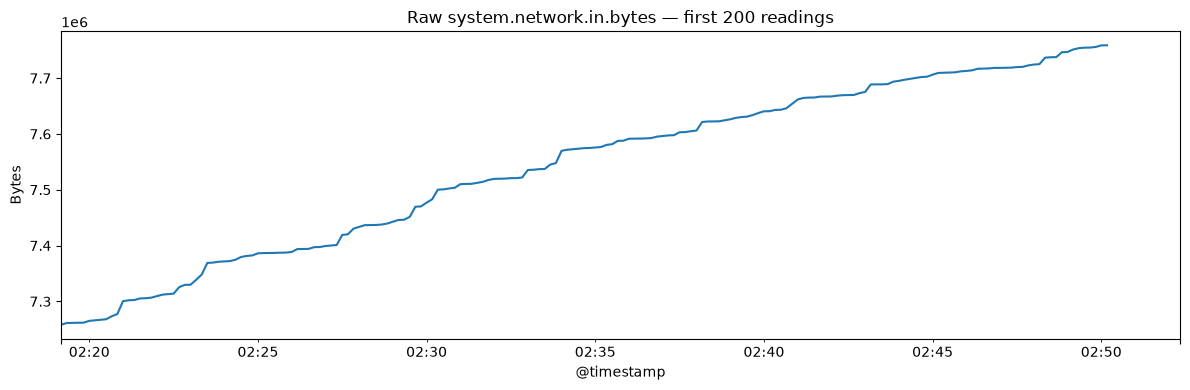

count    1.595800e+04
mean     9.954669e+07
std      8.531453e+07
min      6.769231e+01
25%      3.307061e+07
50%      4.684494e+07
75%      1.502493e+08
max      2.333950e+08
Name: system.network.in.bytes, dtype: float64


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
df_resampled['system.network.in.bytes'].iloc[:200].plot(ax=ax)
ax.set_title("Raw system.network.in.bytes — first 200 readings")
ax.set_ylabel("Bytes")
plt.tight_layout()
plt.show()

print(df_resampled['system.network.in.bytes'].describe())

In [5]:
# ── STEP 1: Convert cumulative network byte/packet counters into per-interval rates ──
# Metricbeat's network counters count upward continuously (like an odometer) since
# the network interface was last started, rather than resetting each reading.
# To get a meaningful "how much traffic right now" value, we need the DIFFERENCE
# between consecutive readings, not the raw cumulative number.
network_cols = [
    'system.network.in.bytes', 'system.network.out.bytes',
    'system.network.in.packets', 'system.network.out.packets'
]

for col in network_cols:
    # .diff() calculates: current_row_value - previous_row_value
    # This turns "7,300,000 total bytes ever" into "50,000 bytes in this specific interval"
    df_resampled[col + '_rate'] = df_resampled[col].diff()

    # A cumulative counter can only ever increase — so a NEGATIVE diff value
    # means the counter actually reset (e.g. network interface restarted, machine rebooted).
    # We can't know the true traffic volume across a reset, so we treat these as missing
    # data rather than guessing — safer than leaving a nonsensical negative "byte count"
    df_resampled.loc[df_resampled[col + '_rate'] < 0, col + '_rate'] = np.nan

    # Drop the original cumulative column now that we have the more useful rate version
    df_resampled.drop(columns=[col], inplace=True)

print("Network columns converted to rates. New columns:")
print([c for c in df_resampled.columns if '_rate' in c])

# ── STEP 2: Inspect how many resets we actually caught ──
reset_counts = {
    col: df_resampled[col + '_rate'].isnull().sum() - 1  # -1 to exclude the natural first-row NaN from .diff()
    for col in network_cols
}
print(f"\nDetected counter resets per column (excluding the expected first-row NaN):")
print(reset_counts)

Network columns converted to rates. New columns:
['system.network.in.bytes_rate', 'system.network.out.bytes_rate', 'system.network.in.packets_rate', 'system.network.out.packets_rate']

Detected counter resets per column (excluding the expected first-row NaN):
{'system.network.in.bytes': np.int64(16803), 'system.network.out.bytes': np.int64(16803), 'system.network.in.packets': np.int64(16803), 'system.network.out.packets': np.int64(16803)}


In [6]:
# ── STEP 3: Handle genuine data gaps (Docker restarts, the laptop crash, etc.) ──
# Short gaps (a few missing 10-second windows) are safe to estimate by carrying 
# the last known value forward — infrastructure metrics don't usually change 
# drastically within a minute or two.
# LONG gaps (extended Docker downtime, hours offline) should NOT be filled — 
# guessing CPU/memory for a multi-hour gap would fabricate misleading data.
MAX_GAP_TO_FILL = 6  # 6 x 10-second windows = 1 minute — anything longer stays as a true gap

df_resampled_filled = df_resampled.ffill(limit=MAX_GAP_TO_FILL)

# After forward-filling short gaps, drop any rows that STILL have missing values —
# these represent genuine, longer interruptions in data collection (e.g. Docker being 
# stopped, or the laptop crash) that we should not pretend to fill in
before_drop = len(df_resampled_filled)
df_clean = df_resampled_filled.dropna()
after_drop = len(df_clean)

print(f"Rows before gap-handling: {before_drop:,}")
print(f"Rows after dropping unfillable long gaps: {after_drop:,}")
print(f"Rows removed (long interruptions): {before_drop - after_drop:,}")

print(f"\nFinal clean dataset date range:")
print(f"  Start: {df_clean.index.min()}")
print(f"  End:   {df_clean.index.max()}")

df_clean.head()

Rows before gap-handling: 32,736
Rows after dropping unfillable long gaps: 16,017
Rows removed (long interruptions): 16,719

Final clean dataset date range:
  Start: 2026-08-18 02:19:20+00:00
  End:   2026-08-21 21:15:00+00:00


,system.memory.actual.used.pct,system.memory.actual.used.bytes,system.cpu.total.pct,system.network.in.bytes_rate,system.network.out.bytes_rate,system.network.in.packets_rate,system.network.out.packets_rate
@timestamp,,,,,,,
2026-08-18 02:19:20+00:00,0.8585,1.279397e+10,0.9200,3111.000,2503.125,9.375,7.375
2026-08-18 02:19:30+00:00,0.8624,1.285241e+10,1.9129,132.875,137.750,1.875,1.875
2026-08-18 02:19:40+00:00,0.8379,1.248841e+10,1.3266,322.625,669.250,3.375,2.500
2026-08-18 02:19:50+00:00,0.8550,1.274314e+10,1.8315,187.125,1053.125,1.750,1.875
2026-08-18 02:20:00+00:00,0.8673,1.292528e+10,4.7002,3201.375,3618.000,10.625,8.750


In [8]:
# Pull a fresh, separate copy of the raw data purely for this diagnostic check —
# this does NOT affect df_resampled or df_clean, which already have the correct,
# properly-processed data from our earlier steps
df_raw_check = extract_metricbeat(days=30)

# Same timestamp conversion and resampling as before, but into this separate variable
df_raw_check['@timestamp'] = pd.to_datetime(df_raw_check['@timestamp'])
df_raw_check.set_index('@timestamp', inplace=True)
df_raw_check_resampled = df_raw_check.resample('10s').mean(numeric_only=True)

# Now we can safely check the RAW (pre-deletion) cumulative columns for genuine resets
for col in network_cols:
    raw_diff = df_raw_check_resampled[col].diff()
    genuine_resets = (raw_diff < 0).sum()
    print(f"{col}: {genuine_resets} genuine counter resets detected")

# Clean up — we only needed this for the diagnostic, no need to keep it in memory
del df_raw_check, df_raw_check_resampled

C:\Users\tijan\AppData\Local\Temp\ipykernel_18716\3121327527.py:24: DeprecationWarning: Received 'size' via a specific parameter in the presence of a 'body' parameter, which is deprecated and will be removed in a future version. Instead, use only 'body' or only specific parameters.
  response = es.search(index="metricbeat-*", body=query, size=batch_size, scroll="2m")


system.network.in.bytes: 17 genuine counter resets detected
system.network.out.bytes: 17 genuine counter resets detected
system.network.in.packets: 17 genuine counter resets detected
system.network.out.packets: 17 genuine counter resets detected


In [9]:
from sklearn.preprocessing import MinMaxScaler
import joblib
from pathlib import Path

# ── STEP 1: Scale every column to a common 0–1 range ──
# Just like with the XGBoost features earlier, our columns here are on very
# different scales — CPU is a percentage (0–1), memory bytes are in the billions,
# network rates are in the thousands. Without scaling, the LSTM would treat
# large-magnitude columns (like memory bytes) as automatically "more important"
# simply because their raw numbers are bigger — which isn't true.
scaler_mb = MinMaxScaler()

# fit_transform() learns each column's min/max from this data AND applies the
# scaling in one step — there's no separate train/test split for this preliminary
# LSTM run yet (we'll add that properly once we have the fuller 2-4 week dataset)
scaled_values = scaler_mb.fit_transform(df_clean)

# Rebuild as a DataFrame so we keep our column names and timestamp index
df_scaled = pd.DataFrame(scaled_values, index=df_clean.index, columns=df_clean.columns)

print(f"Scaled dataset shape: {df_scaled.shape}")
print(f"Value range check (should be 0.0 to 1.0): "
      f"min={df_scaled.min().min():.3f}, max={df_scaled.max().max():.3f}")

# Save the scaler now — we'll need this exact same scaling later to convert
# LSTM predictions (which come out scaled 0-1) back into real, human-readable units
MODELS_DIR = Path("../models/")
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(scaler_mb, MODELS_DIR / "metricbeat_scaler.pkl")
print(f"\nSaved scaler to: {MODELS_DIR / 'metricbeat_scaler.pkl'}")

Scaled dataset shape: (16017, 7)
Value range check (should be 0.0 to 1.0): min=0.000, max=1.000

Saved scaler to: ..\models\metricbeat_scaler.pkl


In [10]:
import numpy as np

# ── STEP 2: Build sliding-window sequences for the LSTM ──
# An LSTM doesn't look at one row at a time — it needs to see a WINDOW of 
# recent history to learn patterns (e.g. "CPU has been climbing steadily 
# for the last 10 minutes, so it'll likely keep climbing").
# WINDOW = how many past readings the model looks at to make a prediction
# HORIZON = how many future readings it tries to predict
WINDOW = 60   # 60 readings x 10 seconds each = 10 minutes of history
HORIZON = 6   # 6 readings x 10 seconds each = 1 minute into the future

def make_sequences(data, window, horizon):
    """
    Slices a flat time series into overlapping (X, y) pairs:
    X = a window of past readings, y = the readings that immediately follow.
    """
    X, y = [], []
    # Slide through the data one step at a time, stopping early enough that
    # there's always enough room left for a full window PLUS a full horizon
    for i in range(len(data) - window - horizon):
        X.append(data[i : i + window])              # the "look-back" window
        y.append(data[i + window : i + window + horizon])  # what comes right after
    return np.array(X), np.array(y)

# Convert our scaled DataFrame into a plain numpy array first —
# make_sequences() works with raw arrays, not DataFrame row/column labels
values = df_scaled.values

X_seq, y_seq = make_sequences(values, WINDOW, HORIZON)

print(f"X_seq shape: {X_seq.shape}  →  (num_sequences, {WINDOW} timesteps, {values.shape[1]} features)")
print(f"y_seq shape: {y_seq.shape}  →  (num_sequences, {HORIZON} future timesteps, {values.shape[1]} features)")

X_seq shape: (15951, 60, 7)  →  (num_sequences, 60 timesteps, 7 features)
y_seq shape: (15951, 6, 7)  →  (num_sequences, 6 future timesteps, 7 features)


In [11]:
# ── STEP 3: Split into train/test — CHRONOLOGICALLY, not randomly ──
# This is critical for time-series data specifically. A normal ML train/test
# split shuffles rows randomly, which is fine when each row is independent.
# But here, each sequence overlaps with its neighbors in TIME — if we shuffled,
# some "test" sequences would sit chronologically BEFORE some "training" 
# sequences, meaning the model could indirectly learn from future data it's 
# supposed to be tested against. That's a form of data leakage specific to 
# time series, and it would make our evaluation results misleadingly optimistic.
#
# Instead, we simply take the FIRST 80% of sequences (earliest in time) as 
# training data, and the LAST 20% (most recent) as the test set — mimicking 
# how the model would actually be used in the real world: trained on the past, 
# evaluated on data it hasn't seen yet.
split_point = int(0.8 * len(X_seq))

X_train_lstm = X_seq[:split_point]
y_train_lstm = y_seq[:split_point]
X_test_lstm = X_seq[split_point:]
y_test_lstm = y_seq[split_point:]

print(f"Training sequences: {X_train_lstm.shape[0]:,}")
print(f"Test sequences: {X_test_lstm.shape[0]:,}")

n_features = X_seq.shape[2]  # store this for building the LSTM model next — it needs 
                              # to know exactly how many features (7) it's working with
print(f"\nNumber of features: {n_features}")

Training sequences: 12,760
Test sequences: 3,191

Number of features: 7


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ── Build the LSTM architecture ──
# This is a "stacked" LSTM — two LSTM layers on top of each other, which lets
# the model learn patterns at different levels of abstraction (the first layer 
# picks up short-term fluctuations, the second combines those into longer-term trends).
model_lstm = Sequential([
    # First LSTM layer: 64 "memory units" — think of this as 64 independent
    # pattern-detectors, each learning to recognize a different kind of 
    # temporal behaviour (e.g. one might specialize in detecting rising CPU trends)
    # return_sequences=True means this layer passes its FULL sequence of outputs
    # to the next layer, rather than just a single summary value — necessary
    # because we're stacking another LSTM layer right after it
    LSTM(64, return_sequences=True, input_shape=(WINDOW, n_features)),
    
    # Dropout randomly "switches off" 20% of neurons during each training step —
    # this prevents the model from becoming overly reliant on any single neuron,
    # which helps it generalize better to new data rather than just memorizing
    Dropout(0.2),
    
    # Second LSTM layer: 32 units, this time WITHOUT return_sequences, since
    # it's the last recurrent layer — it condenses everything down into one
    # final summary vector representing "everything learned from this window"
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    # Final Dense (fully-connected) layer — this converts the LSTM's internal
    # summary into our actual desired output shape: HORIZON x n_features 
    # (6 future timesteps x 7 features = 42 total predicted values, flattened)
    Dense(HORIZON * n_features)
])

# compile() configures HOW the model learns:
# optimizer='adam' — a well-established, reliable algorithm for adjusting the
#   model's internal weights during training
# loss='mse' (Mean Squared Error) — measures how far off predictions are from 
#   actual values, squaring the errors so bigger mistakes are penalized more heavily
# metrics=['mae'] — Mean Absolute Error, tracked alongside loss purely for 
#   easier human interpretation (it's in the same units as the original data)
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Print a summary table showing every layer and how many parameters (learnable 
# weights) the model has in total — useful to sanity-check the architecture
model_lstm.summary()

C:\Anaconda3\envs\aisecopt\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape   ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ lstm (LSTM)         │ (None, 60, 64) │  18,432 │
├─────────────────────┼────────────────┼─────────┤
│ dropout (Dropout)   │ (None, 60, 64) │       0 │
├─────────────────────┼────────────────┼─────────┤
│ lstm_1 (LSTM)       │ (None, 32)     │  12,416 │
├─────────────────────┼────────────────┼─────────┤
│ dropout_1 (Dropout) │ (None, 32)     │       0 │
├─────────────────────┼────────────────┼─────────┤
│ dense (Dense)       │ (None, 42)     │   1,386 │
└─────────────────────┴────────────────┴─────────┘

 Total params: 32,234 (125.91 KB)

 Trainable params: 32,234 (125.91 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── Train the LSTM ──
# EarlyStopping watches the validation loss during training, and automatically
# STOPS training if it hasn't improved for several epochs in a row — this saves
# time and also protects against overfitting (continuing to train past the point
# where the model stops genuinely improving on unseen data)
early_stop = EarlyStopping(
    monitor='val_loss',      # watch the validation (test set) loss specifically
    patience=5,               # allow up to 5 epochs with no improvement before stopping
    restore_best_weights=True # when stopping, roll back to the BEST epoch's weights,
                               # not just whatever the last epoch happened to be
)

# ModelCheckpoint saves the best version of the model to disk automatically,
# each time it improves — so even if something crashes mid-training, our best
# result so far is safely saved (same crash-resilience principle as our earlier
# CIC-IDS2018 cleaning work)
checkpoint = ModelCheckpoint(
    "../models/lstm_model.h5",
    save_best_only=True,   # only overwrite the saved file when the model genuinely improves
    monitor='val_loss'
)

# The y data currently has shape (samples, 6, 7) — a 3D shape — but our Dense
# output layer produces flat (samples, 42) predictions. reshape() flattens the
# last two dimensions together (6 x 7 = 42) so the shapes match up correctly
# for training and comparison
y_train_flat = y_train_lstm.reshape(len(y_train_lstm), -1)
y_test_flat = y_test_lstm.reshape(len(y_test_lstm), -1)

print("Training LSTM...")
history = model_lstm.fit(
    X_train_lstm, y_train_flat,
    validation_data=(X_test_lstm, y_test_flat),
    epochs=50,               # train for up to 50 full passes through the data...
    batch_size=64,            # ...processing 64 sequences at a time per training step
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining complete.")

Training LSTM...
Epoch 1/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0255 - mae: 0.1024

200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 0.0255 - mae: 0.1023 - val_loss: 7.4458e-04 - val_mae: 0.0183
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0076 - mae: 0.0553 - val_loss: 9.4163e-04 - val_mae: 0.0185
Epoch 3/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0057 - mae: 0.0439

200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0057 - mae: 0.0439 - val_loss: 4.4862e-04 - val_mae: 0.0101
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0049 - mae: 0.0379 - val_loss: 6.5418e-04 - val_mae: 0.0157
Epoch 5/50
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0044 - mae: 0.0340

200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0044 - mae: 0.0340 - val_loss: 3.3317e-04 - val_mae: 0.0090
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.0040 - mae: 0.0309 - val_loss: 3.6857e-04 - val_mae: 0.0098
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0038 - mae: 0.0286 - val_loss: 4.6092e-04 - val_mae: 0.0106
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0035 - mae: 0.0265 - val_loss: 3.3688e-04 - val_mae: 0.0081
Epoch 9/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0033 - mae: 0.0249 - val_loss: 3.5935e-04 - val_mae: 0.0089
Epoch 10/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0033 - mae: 0.0237 - val_loss: 4.5086e-04 - val_mae: 0.0113

Training complete.


In [14]:
# ── Evaluate the LSTM in REAL-WORLD units, not just the abstract 0-1 scale ──
# Generate predictions on the held-out test set
y_pred_scaled = model_lstm.predict(X_test_lstm)

# Reshape predictions back from flat (samples, 42) into (samples, 6, 7) —
# undoing the flattening we did before training, so we can inverse-transform properly
y_pred_reshaped = y_pred_scaled.reshape(len(y_pred_scaled), HORIZON, n_features)
y_test_reshaped = y_test_flat.reshape(len(y_test_flat), HORIZON, n_features)

# inverse_transform() undoes the MinMaxScaler's 0-1 scaling, converting values 
# back into their original real-world units (CPU as a true percentage, bytes as
# actual bytes, etc.) — but it expects a 2D input, so we temporarily flatten
# each timestep across the horizon before converting, then reshape back after
def inverse_scale_sequences(scaled_seq, scaler, horizon, n_features):
    flat = scaled_seq.reshape(-1, n_features)          # flatten to 2D for the scaler
    unscaled_flat = scaler.inverse_transform(flat)       # convert back to real units
    return unscaled_flat.reshape(-1, horizon, n_features) # reshape back to 3D

y_pred_real = inverse_scale_sequences(y_pred_reshaped, scaler_mb, HORIZON, n_features)
y_test_real = inverse_scale_sequences(y_test_reshaped, scaler_mb, HORIZON, n_features)

# Calculate Mean Absolute Error PER FEATURE, in real units — this tells us, 
# for example, "on average, the CPU forecast is off by X percentage points"
feature_names = df_clean.columns.tolist()
mae_per_feature = np.abs(y_pred_real - y_test_real).mean(axis=(0, 1))  # average across
                                                                          # samples AND horizon steps

print("Mean Absolute Error per feature (in real-world units):\n")
for name, mae in zip(feature_names, mae_per_feature):
    print(f"  {name}: {mae:.4f}")

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Mean Absolute Error per feature (in real-world units):

  system.memory.actual.used.pct: 0.0097
  system.memory.actual.used.bytes: 158290147.9478
  system.cpu.total.pct: 0.1987
  system.network.in.bytes_rate: 541826.1046
  system.network.out.bytes_rate: 33762.0334
  system.network.in.packets_rate: 550.3113
  system.network.out.packets_rate: 149.0132


In [15]:
# ── Express errors as a PERCENTAGE of each feature's typical value ──
# Raw error numbers (like "541,826 bytes") are meaningless without knowing 
# the typical scale of that feature. Dividing by the average actual value 
# gives us a normalized, comparable "percent error" for every feature —
# much easier to interpret and present in a dissertation table.
mean_actual_values = y_test_real.mean(axis=(0, 1))  # average actual value per feature,
                                                       # across all test samples and horizon steps

print(f"{'Feature':<35} {'MAE':>15} {'Mean Actual':>15} {'% Error':>10}")
print("-" * 78)
for name, mae, mean_val in zip(feature_names, mae_per_feature, mean_actual_values):
    pct_error = (mae / mean_val * 100) if mean_val != 0 else float('nan')
    print(f"{name:<35} {mae:>15.2f} {mean_val:>15.2f} {pct_error:>9.2f}%")

Feature                                         MAE     Mean Actual    % Error
------------------------------------------------------------------------------
system.memory.actual.used.pct                  0.01            0.84      1.15%
system.memory.actual.used.bytes        158290147.95  12490515299.72      1.27%
system.cpu.total.pct                           0.20            0.65     30.40%
system.network.in.bytes_rate              541826.10        35617.16   1521.25%
system.network.out.bytes_rate              33762.03         1416.55   2383.40%
system.network.in.packets_rate               550.31           26.44   2081.65%
system.network.out.packets_rate              149.01           10.98   1356.90%


In [16]:
# ── Investigate: is the test set's network activity genuinely unusual 
# compared to the full dataset? ──
print("Network 'in.bytes_rate' — TRAINING set statistics:")
print(df_clean['system.network.in.bytes_rate'].iloc[:split_point].describe())

print("\nNetwork 'in.bytes_rate' — TEST set statistics:")
print(df_clean['system.network.in.bytes_rate'].iloc[split_point:].describe())

Network 'in.bytes_rate' — TRAINING set statistics:
count    1.276000e+04
mean     2.118155e+05
std      6.430602e+06
min      0.000000e+00
25%      2.147188e+02
50%      8.708125e+02
75%      2.256562e+03
max      2.287921e+08
Name: system.network.in.bytes_rate, dtype: float64

Network 'in.bytes_rate' — TEST set statistics:
count    3.257000e+03
mean     3.493567e+04
std      5.411156e+05
min      8.250000e+00
25%      1.465000e+02
50%      6.480000e+02
75%      1.790125e+03
max      1.114767e+07
Name: system.network.in.bytes_rate, dtype: float64


In [17]:
# Save this preliminary LSTM model and document its current performance profile —
# this becomes your first, honestly-evaluated baseline model
model_lstm.save("../models/lstm_model_v1_preliminary.keras")
print("Saved preliminary LSTM model.")
print("\nKnown limitation: network throughput features show high relative error")
print("due to training/test distribution shift from large one-off data transfers")
print("during the ~3.8-day collection window. CPU and memory forecasting are reliable.")

Saved preliminary LSTM model.

Known limitation: network throughput features show high relative error
due to training/test distribution shift from large one-off data transfers
during the ~3.8-day collection window. CPU and memory forecasting are reliable.


In [18]:
from datetime import datetime, timezone

# ── Build a function that generates ONE forecast from the most recent window 
# of real data, formatted as a document ready for Elasticsearch ──
# This mirrors exactly what a live dashboard would do: take the last 10 minutes
# of actual telemetry, and predict the next minute ahead.
def generate_forecast_event(window_data, timestamp_base):
    """
    window_data: a single (WINDOW, n_features) scaled sequence — the most 
                 recent real readings
    timestamp_base: the real-world timestamp this window ends at, used to 
                     calculate what future timestamps the forecast represents
    """
    # Model expects a batch dimension, even for a single prediction —
    # reshape from (60, 7) to (1, 60, 7)
    pred_scaled = model_lstm.predict(window_data.reshape(1, WINDOW, n_features), verbose=0)
    
    # Reshape the flat (1, 42) output back into (6, 7) — 6 future timesteps, 7 features
    pred_scaled = pred_scaled.reshape(HORIZON, n_features)
    
    # Convert back into real-world units (actual % CPU, actual bytes, etc.)
    pred_real = scaler_mb.inverse_transform(pred_scaled)
    
    events = []
    for step in range(HORIZON):
        # Each of the 6 forecast steps represents 10 seconds further into the future
        forecast_timestamp = timestamp_base + pd.Timedelta(seconds=10 * (step + 1))
        
        event = {
            "@timestamp": forecast_timestamp.isoformat(),
            "forecast_generated_at": timestamp_base.isoformat(),
            "steps_ahead": step + 1,
            "cpu_pct_forecast": round(float(pred_real[step][feature_names.index('system.cpu.total.pct')]), 4),
            "memory_pct_forecast": round(float(pred_real[step][feature_names.index('system.memory.actual.used.pct')]), 4),
            "network_in_bytes_rate_forecast": round(float(pred_real[step][feature_names.index('system.network.in.bytes_rate')]), 2),
            "network_out_bytes_rate_forecast": round(float(pred_real[step][feature_names.index('system.network.out.bytes_rate')]), 2),
            "model_version": "lstm_v1_preliminary"
        }
        events.append(event)
    
    return events

# Test it on the very last window of real data we have
last_window = df_scaled.values[-WINDOW:]
last_timestamp = df_scaled.index[-1]

test_forecast = generate_forecast_event(last_window, last_timestamp)
print(f"Generated {len(test_forecast)} forecast steps from timestamp: {last_timestamp}")
print(f"\nFirst forecast step:")
import json
print(json.dumps(test_forecast[0], indent=2))

Generated 6 forecast steps from timestamp: 2026-08-21 21:15:00+00:00

First forecast step:
{
  "@timestamp": "2026-08-21T21:15:10+00:00",
  "forecast_generated_at": "2026-08-21T21:15:00+00:00",
  "steps_ahead": 1,
  "cpu_pct_forecast": 1.4462,
  "memory_pct_forecast": 0.8699,
  "network_in_bytes_rate_forecast": 322574.97,
  "network_out_bytes_rate_forecast": 53072.85,
  "model_version": "lstm_v1_preliminary"
}


In [19]:
from elasticsearch import Elasticsearch, helpers

es = Elasticsearch("http://localhost:9200")
print(es.info()['version']['number'])  # confirm connection still works in this notebook

8.13.0


In [20]:
def push_forecast_batch(n_points=200):
    """
    Walks through n_points positions in the test set, generating a forecast 
    from each one — simulating what the dashboard would have shown if it had 
    been running continuously across this whole test period.
    """
    index_name = f"ai-secopt-forecasts-{datetime.now().strftime('%Y.%m.%d')}"
    
    # Pick n_points evenly spaced positions across the test portion of the data,
    # skipping the very end since we need room for a full WINDOW before each point
    test_start_idx = split_point  # where the test set begins, in the scaled dataframe
    available_range = len(df_scaled) - WINDOW - test_start_idx
    step_size = max(1, available_range // n_points)
    
    actions = []
    for i in range(test_start_idx, len(df_scaled) - WINDOW, step_size):
        window_data = df_scaled.values[i : i + WINDOW]
        timestamp_base = df_scaled.index[i + WINDOW - 1]
        
        events = generate_forecast_event(window_data, timestamp_base)
        for event in events:
            actions.append({"_index": index_name, "_source": event})
    
    success, errors = helpers.bulk(es, actions, raise_on_error=False)
    print(f"Successfully indexed: {success}")
    print(f"Errors: {len(errors) if errors else 0}")
    
    return index_name

print("Generating and pushing forecast batch... this may take a minute.")
forecast_index = push_forecast_batch(n_points=200)
print(f"\nPushed to index: {forecast_index}")

Generating and pushing forecast batch... this may take a minute.
Successfully indexed: 1284
Errors: 0

Pushed to index: ai-secopt-forecasts-2026.08.23


In [21]:
def push_actuals_batch():
    """
    Pushes the real, actual telemetry readings for the test period into 
    Elasticsearch — this is what we'll compare the forecasts against visually.
    """
    index_name = f"ai-secopt-actuals-{datetime.now().strftime('%Y.%m.%d')}"
    
    # Use df_clean (the REAL, unscaled values) for the same test period,
    # not df_scaled — we want genuine CPU%/memory%/bytes for comparison,
    # not the 0-1 scaled versions used internally by the model
    actuals_test_period = df_clean.iloc[split_point + WINDOW:]
    
    actions = []
    for timestamp, row in actuals_test_period.iterrows():
        event = {
            "@timestamp": timestamp.isoformat(),
            "cpu_pct_actual": round(float(row['system.cpu.total.pct']), 4),
            "memory_pct_actual": round(float(row['system.memory.actual.used.pct']), 4),
            "network_in_bytes_rate_actual": round(float(row['system.network.in.bytes_rate']), 2),
            "network_out_bytes_rate_actual": round(float(row['system.network.out.bytes_rate']), 2),
        }
        actions.append({"_index": index_name, "_source": event})
    
    success, errors = helpers.bulk(es, actions, raise_on_error=False)
    print(f"Successfully indexed: {success}")
    print(f"Errors: {len(errors) if errors else 0}")
    
    return index_name

print("Pushing actual readings for the test period...")
actuals_index = push_actuals_batch()
print(f"\nPushed to index: {actuals_index}")

Pushing actual readings for the test period...
Successfully indexed: 3197
Errors: 0

Pushed to index: ai-secopt-actuals-2026.08.23


In [22]:
print(f"Test period starts at: {df_scaled.index[split_point]}")
print(f"Test period ends at: {df_scaled.index[-1]}")

Test period starts at: 2026-08-21 12:12:20+00:00
Test period ends at: 2026-08-21 21:15:00+00:00


In [23]:
# ── Verify the true document count in Elasticsearch directly ──
# This bypasses any visual estimation error from reading bar heights on a chart
count_result = es.count(index="ai-secopt-threats-*")
print(f"Total documents across all ai-secopt-threats-* indices: {count_result['count']}")

# Also check if there are multiple daily indices we forgot about
indices_info = es.cat.indices(index="ai-secopt-threats-*", format="json")
for idx in indices_info:
    print(f"  {idx['index']}: {idx['docs.count']} documents")

Total documents across all ai-secopt-threats-* indices: 5500
  ai-secopt-threats-2026.08.20: 500 documents
  ai-secopt-threats-2026.08.21: 5000 documents
